In [2]:
import json
import spacy

# Load spaCy for concept extraction - keep this simple
nlp = spacy.load("en_core_web_sm")

# File path - replace with your actual file path
file_path = "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json"

# Load the data
with open(file_path, "r") as file:
    data = json.load(file)

# Initialize counters
model_stats = {}

# Process each entry in the file
for key, item in data.items():
    # Get model name (like "llama2" from "llama2_0")
    model_name = key.split("_")[0]
    
    # Initialize model stats if we haven't seen this model yet
    if model_name not in model_stats:
        model_stats[model_name] = {
            "raw_correct": 0,
            "onto_correct": 0,
            "total": 0,
            "raw_concepts": [],
            "onto_concepts": []
        }
    
    # Get the correct answer
    question = item["question"]
    correct_answer_index = int(question["answer"])
    correct_answer = question["choices"][correct_answer_index].lower()
    
    # Get the responses
    raw_response = item.get("raw_model_response", "").lower()
    onto_response = item.get("onto_model_response", "").lower()
    
    # Check if correct answer appears in responses (simple approach)
    raw_correct = correct_answer in raw_response
    onto_correct = correct_answer in onto_response
    
    # Update accuracy counts
    if raw_correct:
        model_stats[model_name]["raw_correct"] += 1
    if onto_correct:
        model_stats[model_name]["onto_correct"] += 1
    
    model_stats[model_name]["total"] += 1
    
    # Count concepts (entities and noun chunks) - simple approach
    raw_doc = nlp(raw_response)
    onto_doc = nlp(onto_response)
    
    # Collect entities and noun chunks
    raw_concepts = set([ent.text.lower() for ent in raw_doc.ents] + 
                    [chunk.text.lower() for chunk in raw_doc.noun_chunks])
    onto_concepts = set([ent.text.lower() for ent in onto_doc.ents] + 
                      [chunk.text.lower() for chunk in onto_doc.noun_chunks])
    
    # Store concept counts
    model_stats[model_name]["raw_concepts"].append(len(raw_concepts))
    model_stats[model_name]["onto_concepts"].append(len(onto_concepts))

# Calculate summary metrics
for model, stats in model_stats.items():
    total = stats["total"]
    if total == 0:
        continue
        
    # Calculate accuracy percentages
    raw_accuracy = (stats["raw_correct"] / total) * 100
    onto_accuracy = (stats["onto_correct"] / total) * 100
    
    # Calculate average concept coverage
    avg_raw_concepts = sum(stats["raw_concepts"]) / total
    avg_onto_concepts = sum(stats["onto_concepts"]) / total
    
    # Print results
    print(f"\nModel: {model}")
    print(f"  Questions analyzed: {total}")
    print(f"  Raw Model Accuracy: {raw_accuracy:.2f}%")
    print(f"  Ontology Model Accuracy: {onto_accuracy:.2f}%")
    print(f"  Accuracy Improvement: {onto_accuracy - raw_accuracy:.2f}%")
    print(f"  Avg Raw Concepts: {avg_raw_concepts:.2f}")
    print(f"  Avg Onto Concepts: {avg_onto_concepts:.2f}")
    print(f"  Concept Improvement: {avg_onto_concepts - avg_raw_concepts:.2f}")


Model: llama2
  Questions analyzed: 203
  Raw Model Accuracy: 32.02%
  Ontology Model Accuracy: 46.31%
  Accuracy Improvement: 14.29%
  Avg Raw Concepts: 10.77
  Avg Onto Concepts: 37.06
  Concept Improvement: 26.29

Model: llama3.1
  Questions analyzed: 203
  Raw Model Accuracy: 50.74%
  Ontology Model Accuracy: 84.24%
  Accuracy Improvement: 33.50%
  Avg Raw Concepts: 2.30
  Avg Onto Concepts: 51.69
  Concept Improvement: 49.39

Model: llama3.2
  Questions analyzed: 203
  Raw Model Accuracy: 40.89%
  Ontology Model Accuracy: 67.98%
  Accuracy Improvement: 27.09%
  Avg Raw Concepts: 3.68
  Avg Onto Concepts: 47.06
  Concept Improvement: 43.38

Model: phi4
  Questions analyzed: 203
  Raw Model Accuracy: 80.30%
  Ontology Model Accuracy: 85.22%
  Accuracy Improvement: 4.93%
  Avg Raw Concepts: 23.30
  Avg Onto Concepts: 67.29
  Concept Improvement: 44.00

Model: deepseek-r1:14b
  Questions analyzed: 203
  Raw Model Accuracy: 86.70%
  Ontology Model Accuracy: 84.24%
  Accuracy Improveme

Processed MMLU_highschool_Chem_Full_Dual_annotation0.json: found data for 5 models
Processed MMLU_highschool_Chem_Full_Dual_annotation1.json: found data for 5 models
Processed MMLU_highschool_Chem_Full_Dual_annotation2.json: found data for 5 models

DETAILED METRICS FOR LLM RESPONSES

MODEL: deepseek-r1:14b
--------------------------------------------------------------------------------
File 1:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   84.24% (171/203)
  Improvement:      -2.46%
File 2:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   84.73% (172/203)
  Improvement:      -1.97%
File 3:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   84.73% (172/203)
  Improvement:      -1.97%

Aggregate Statistics:
  Initial Accuracy: 86.70% ± 0.00%
  Final Accuracy:   84.56% ± 0.23%
  Improvement:      -2.13% ± 0.23%
  Avg Questions:    203.0
  ** Statistically significant degradation **

MODEL: llama2
--------------------------------------------------------------------

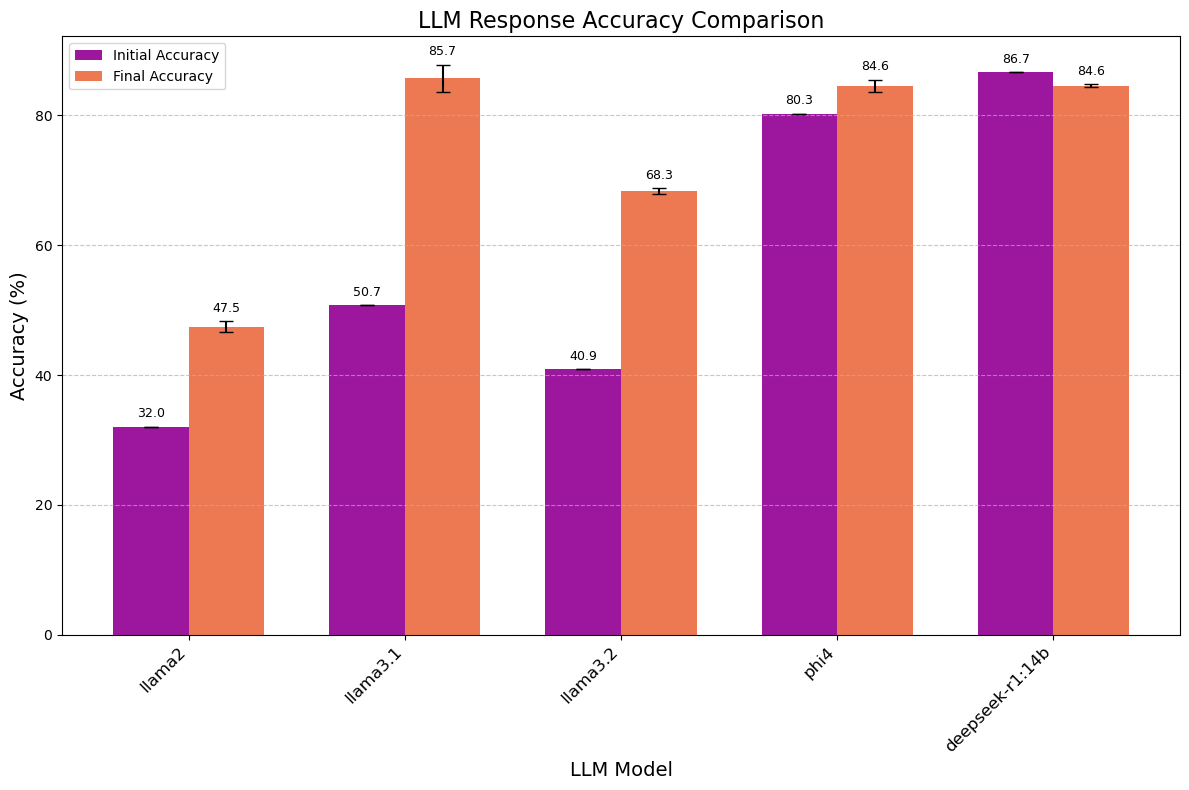

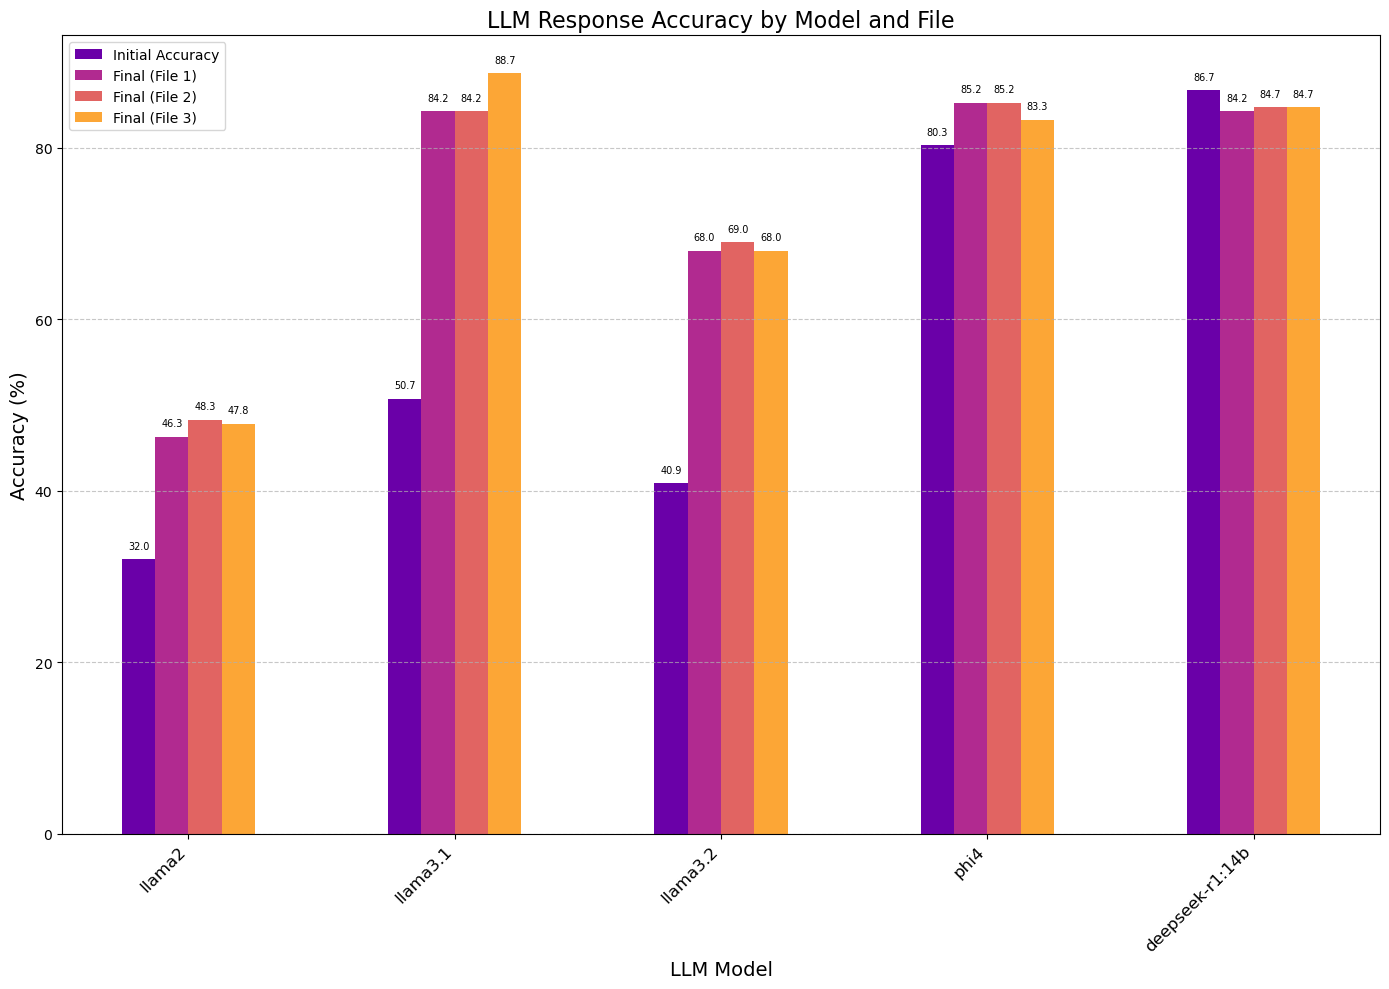

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

def process_llm_response_file(file_path, target_models=None):
    """
    Process a LLM response file and extract metrics based on response correctness.
    
    Args:
        file_path: Path to the JSON file containing LLM responses
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        Dictionary with metrics for each model
    """
    try:
        # Load the JSON file
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Initialize metrics for each model
        model_metrics = defaultdict(lambda: {
            "initial_correct": 0,  # For raw_model_response
            "final_correct": 0,    # For onto_model_response
            "total": 0
        })
        
        # Process each item in the file
        for key, item in data.items():
            # Extract model name from the key (e.g., "llama2_0" -> "llama2")
            model_name = key.split("_")[0]
            
            # Skip if not in target models
            if target_models and not any(model_name.startswith(target) for target in target_models):
                continue
            
            try:
                # Get the correct answer
                correct_answer_index = int(item["question"]["answer"])
                choices = item["question"]["choices"]
                correct_answer = choices[correct_answer_index].lower()
                
                # Check for correctness in both raw and onto responses
                raw_response = item["raw_model_response"].lower()
                onto_response = item["onto_model_response"].lower()
                
                # Increment counters
                model_metrics[model_name]["total"] += 1
                
                if correct_answer in raw_response:
                    model_metrics[model_name]["initial_correct"] += 1
                
                if correct_answer in onto_response:
                    model_metrics[model_name]["final_correct"] += 1
                
            except (KeyError, IndexError, ValueError) as e:
                print(f"Error processing {key} in {file_path}: {e}")
                continue
        
        # Calculate percentages and other metrics
        results = {}
        for model, counts in model_metrics.items():
            if counts["total"] > 0:
                results[model] = {
                    "initial_accuracy": counts["initial_correct"] / counts["total"] * 100,
                    "final_accuracy": counts["final_correct"] / counts["total"] * 100,
                    "improvement": (counts["final_correct"] - counts["initial_correct"]) / counts["total"] * 100,
                    "initial_correct": counts["initial_correct"],
                    "final_correct": counts["final_correct"],
                    "total_questions": counts["total"]
                }
        
        print(f"Processed {os.path.basename(file_path)}: found data for {len(results)} models")
        return results
    
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return {}

def process_multiple_files(file_paths, target_models=None):
    """
    Process multiple LLM response files and combine the results.
    
    Args:
        file_paths: List of paths to JSON files
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        List of results dictionaries, one per file
    """
    all_results = []
    
    for file_path in file_paths:
        results = process_llm_response_file(file_path, target_models)
        if results:
            all_results.append(results)
    
    return all_results

def calculate_aggregate_statistics(all_results):
    """
    Calculate mean and standard deviation metrics across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        
    Returns:
        Tuple of (mean_metrics, std_metrics)
    """
    # Get all unique models
    all_models = set()
    for results in all_results:
        all_models.update(results.keys())
    
    # Initialize containers for aggregated metrics
    mean_metrics = {}
    std_metrics = {}
    
    for model in all_models:
        # Collect metrics for this model across all files
        initial_accuracies = []
        final_accuracies = []
        improvements = []
        initial_corrects = []
        final_corrects = []
        total_questions = []
        
        for results in all_results:
            if model in results:
                initial_accuracies.append(results[model]["initial_accuracy"])
                final_accuracies.append(results[model]["final_accuracy"])
                improvements.append(results[model]["improvement"])
                initial_corrects.append(results[model]["initial_correct"])
                final_corrects.append(results[model]["final_correct"])
                total_questions.append(results[model]["total_questions"])
        
        # Calculate means and standard deviations
        if initial_accuracies:  # Check if we have any data
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "improvement": np.mean(improvements),
                "initial_correct": np.mean(initial_corrects),
                "final_correct": np.mean(final_corrects),
                "total_questions": np.mean(total_questions)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "improvement": np.std(improvements) if len(improvements) > 1 else 0,
                "initial_correct": np.std(initial_corrects) if len(initial_corrects) > 1 else 0,
                "final_correct": np.std(final_corrects) if len(final_corrects) > 1 else 0,
                "total_questions": np.std(total_questions) if len(total_questions) > 1 else 0
            }
    
    return mean_metrics, std_metrics

def print_detailed_metrics(all_results, mean_metrics, std_metrics):
    """
    Print detailed metrics for each model.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
    """
    print("\n" + "=" * 80)
    print("DETAILED METRICS FOR LLM RESPONSES")
    print("=" * 80)
    
    # Get all models in alphabetical order
    models = sorted(mean_metrics.keys())
    
    for model in models:
        print(f"\nMODEL: {model}")
        print("-" * 80)
        
        # Print metrics for each file
        for i, results in enumerate(all_results):
            if model in results:
                print(f"File {i+1}:")
                print(f"  Initial Accuracy: {results[model]['initial_accuracy']:.2f}% ({results[model]['initial_correct']}/{results[model]['total_questions']})")
                print(f"  Final Accuracy:   {results[model]['final_accuracy']:.2f}% ({results[model]['final_correct']}/{results[model]['total_questions']})")
                print(f"  Improvement:      {results[model]['improvement']:.2f}%")
        
        # Print aggregate metrics
        print("\nAggregate Statistics:")
        print(f"  Initial Accuracy: {mean_metrics[model]['initial_accuracy']:.2f}% ± {std_metrics[model]['initial_accuracy']:.2f}%")
        print(f"  Final Accuracy:   {mean_metrics[model]['final_accuracy']:.2f}% ± {std_metrics[model]['final_accuracy']:.2f}%")
        print(f"  Improvement:      {mean_metrics[model]['improvement']:.2f}% ± {std_metrics[model]['improvement']:.2f}%")
        print(f"  Avg Questions:    {mean_metrics[model]['total_questions']:.1f}")
        
        # Calculate statistical significance
        if mean_metrics[model]['improvement'] > 0 and mean_metrics[model]['improvement'] > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant improvement **")
        elif mean_metrics[model]['improvement'] < 0 and abs(mean_metrics[model]['improvement']) > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant degradation **")

def save_metrics_to_json(mean_metrics, std_metrics, output_file='llm_metrics_data_Dual.json'):
    """
    Save the calculated metrics to a JSON file.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all models
    models = sorted(mean_metrics.keys())
    
    # Create serializable data
    data = {
        "llm_names": models,
        "mean_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                       for model, metrics in mean_metrics.items()},
        "std_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                      for model, metrics in std_metrics.items()}
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)
    
    print(f"Metrics saved to {output_file}")

def create_summary_plot(mean_metrics, std_metrics, ordered_models=None, output_file='llm_accuracy_comparison.png'):
    """
    Create a bar plot comparing initial and final accuracy for each model.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get models in specified order or alphabetically
    if ordered_models:
        models = [model for model in ordered_models if model in mean_metrics]
    else:
        models = sorted(mean_metrics.keys())
    
    # Extract metrics for plotting
    initial_accuracies = [mean_metrics[model]["initial_accuracy"] for model in models]
    final_accuracies = [mean_metrics[model]["final_accuracy"] for model in models]
    initial_errors = [std_metrics[model]["initial_accuracy"] for model in models]
    final_errors = [std_metrics[model]["final_accuracy"] for model in models]
    
    # Set up the figure
    plt.figure(figsize=(12, 8))
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.35
    
    # Use plasma colormap
    colors = sns.color_palette("plasma", 2)
    
    # Create the bar chart
    plt.bar(x - width/2, initial_accuracies, width, label='Initial Accuracy', 
            color=colors[0], yerr=initial_errors, capsize=5)
    plt.bar(x + width/2, final_accuracies, width, label='Final Accuracy', 
            color=colors[1], yerr=final_errors, capsize=5)
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy Comparison', fontsize=16)
    plt.xticks(x, models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        plt.text(i - width/2, v + initial_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    for i, v in enumerate(final_accuracies):
        plt.text(i + width/2, v + final_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

def create_grouped_comparison_plot(all_results, ordered_models=None, output_file='llm_response_comparison_by_file.png'):
    """
    Create a grouped bar plot showing final accuracy for each model across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get all unique models
    all_model_names = set()
    for results in all_results:
        all_model_names.update(results.keys())
    
    # Use specified order or alphabetical
    if ordered_models:
        models = [model for model in ordered_models if model in all_model_names]
    else:
        models = sorted(list(all_model_names))
    
    # Set up the figure
    plt.figure(figsize=(14, 10))
    
    # Set up the bar positions
    file_count = len(all_results)
    bar_width = 0.2
    group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
    group_positions = np.arange(len(models)) * (group_width + 0.8)
    
    # Use plasma colormap
    plasma_colors = sns.color_palette("plasma", file_count + 1)
    
    # Plot initial accuracies (only once per model - from first file)
    initial_positions = group_positions
    initial_accuracies = []
    
    for model in models:
        if model in all_results[0]:
            initial_accuracies.append(all_results[0][model]["initial_accuracy"])
        else:
            initial_accuracies.append(0)
    
    plt.bar(
        initial_positions, 
        initial_accuracies, 
        bar_width, 
        color=plasma_colors[0], 
        label="Initial Accuracy"
    )
    
    # Plot final accuracies from each file
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        final_accuracies = []
        
        for model in models:
            if model in results:
                final_accuracies.append(results[model]["final_accuracy"])
            else:
                final_accuracies.append(0)
        
        plt.bar(
            final_positions, 
            final_accuracies, 
            bar_width, 
            color=plasma_colors[file_idx + 1], 
            label=f"Final (File {file_idx + 1})"
        )
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy by Model and File', fontsize=16)
    plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        if v > 0:
            plt.text(
                initial_positions[i],
                v + 1,
                f'{v:.1f}',
                ha='center', va='bottom', fontsize=7
            )
    
    # Add value labels for final accuracies
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        for i, model in enumerate(models):
            if model in results and results[model]["final_accuracy"] > 0:
                plt.text(
                    final_positions[i],
                    results[model]["final_accuracy"] + 1,
                    f'{results[model]["final_accuracy"]:.1f}',
                    ha='center', va='bottom', fontsize=7
                )
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Grouped comparison plot saved to {output_file}")

# Main execution
if __name__ == "__main__":
    # Define the file paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation2.json"
    ]
    
    # Define target models
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]
    
    # Define model order for plots
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Process the files
    all_results = process_multiple_files(file_paths, target_models)
    
    if all_results:
        # Calculate aggregate statistics
        mean_metrics, std_metrics = calculate_aggregate_statistics(all_results)
        
        # Print detailed metrics
        print_detailed_metrics(all_results, mean_metrics, std_metrics)
        
        # Save metrics to JSON
        save_metrics_to_json(mean_metrics, std_metrics)
        
        # Create plots
        create_summary_plot(mean_metrics, std_metrics, ordered_models)
        create_grouped_comparison_plot(all_results, ordered_models)
        
        print("\nProcessing complete!")
    else:
        print("No valid data was processed.")

Error processing file /home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full0.json: [Errno 2] No such file or directory: '/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full0.json'
Processed MMLU_highschool_Chem_Full1.json: found data for 5 models
Processed MMLU_highschool_Chem_Full2.json: found data for 5 models

DETAILED METRICS FOR LLM RESPONSES

MODEL: deepseek-r1:14b
--------------------------------------------------------------------------------
File 1:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   89.16% (181/203)
  Improvement:      2.46%
File 2:
  Initial Accuracy: 92.12% (187/203)
  Final Accuracy:   88.67% (180/203)
  Improvement:      -3.45%

Aggregate Statistics:
  Initial Accuracy: 89.41% ± 2.71%
  Final Accuracy:   88.92% ± 0.25%
  Improvement:      -0.49% ± 2.96%
  Avg Questions:    203.0

MODEL: llama2
--------------------------------------------------------------------------------
File 1:
  Initial Accuracy: 

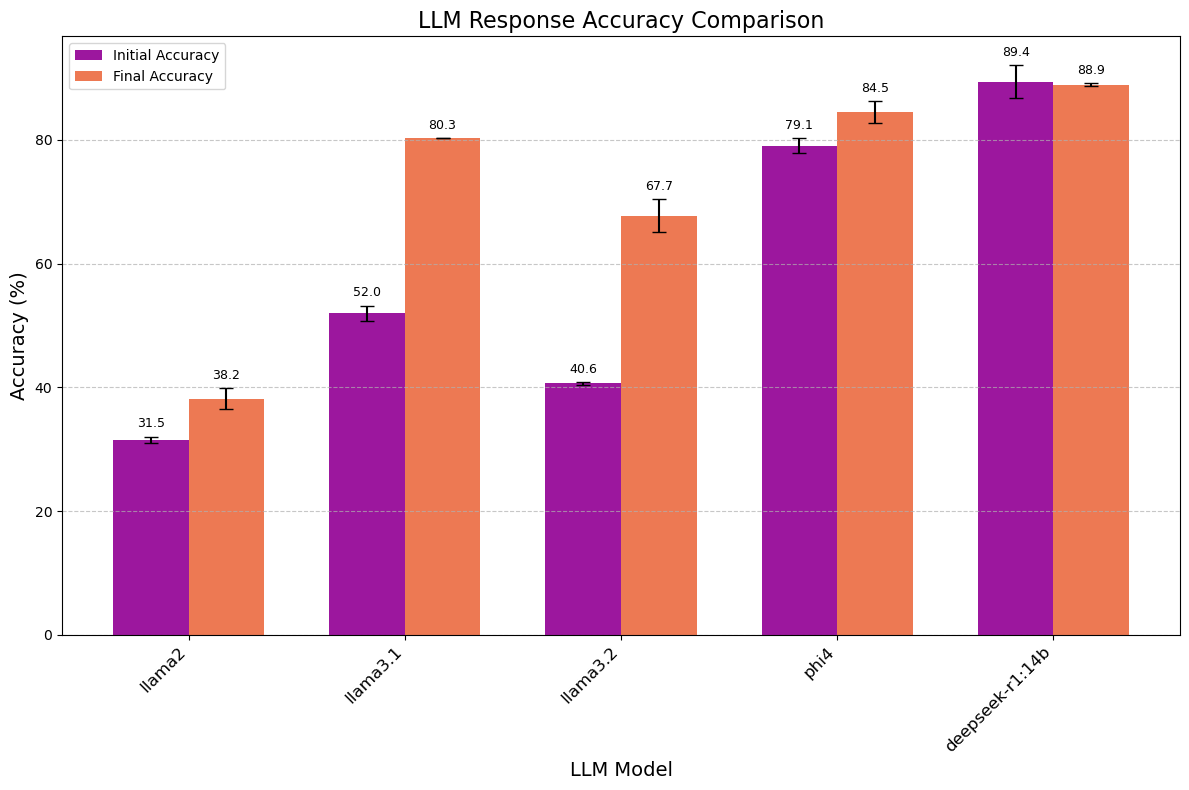

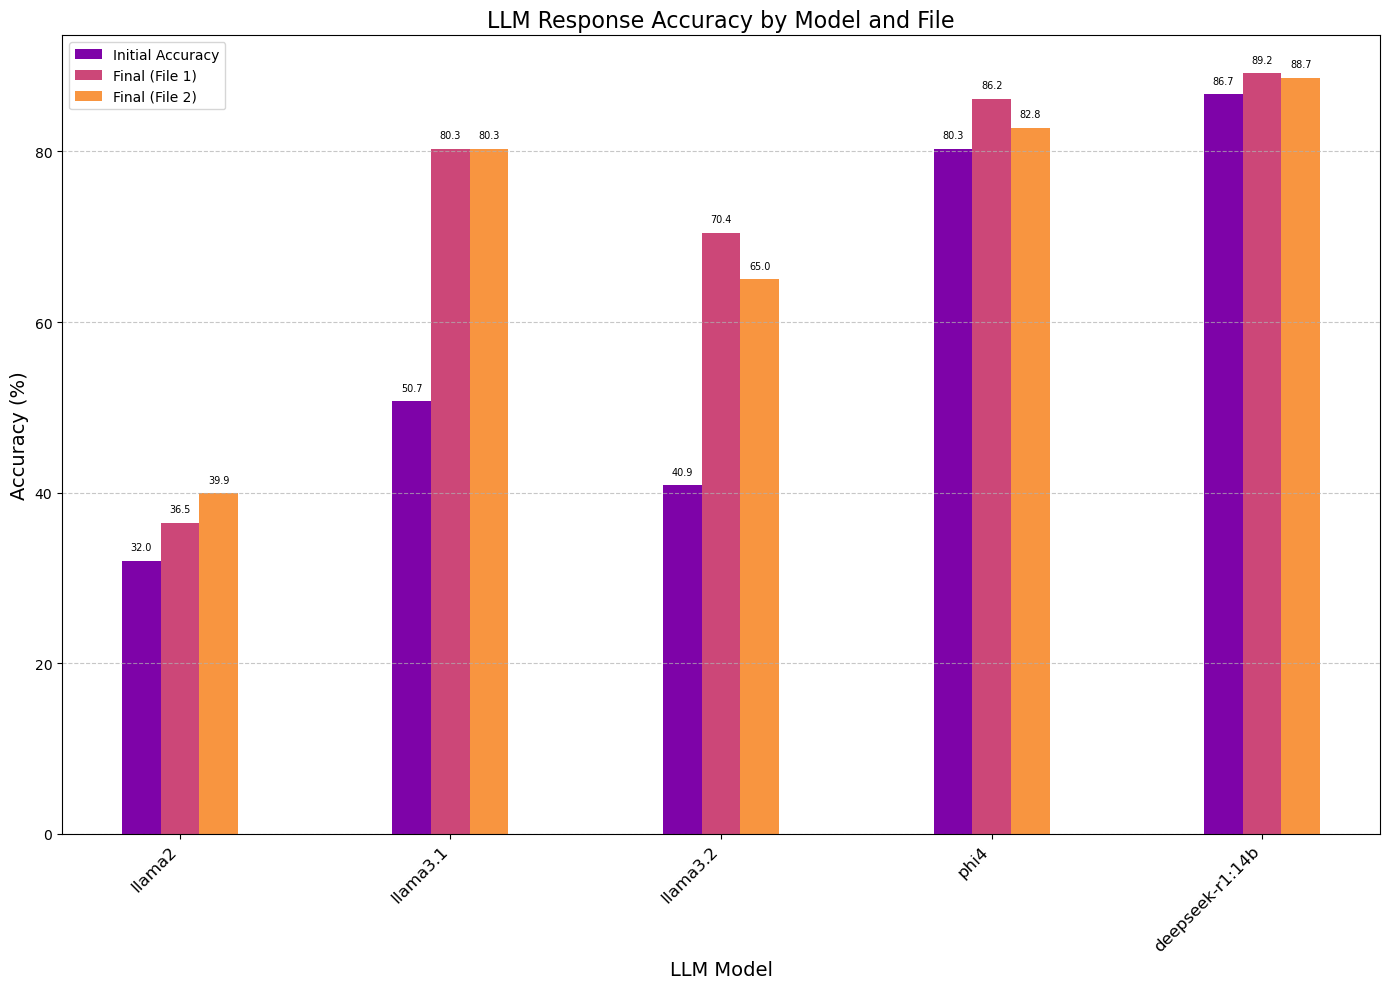

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

def process_llm_response_file(file_path, target_models=None):
    """
    Process a LLM response file and extract metrics based on response correctness.
    
    Args:
        file_path: Path to the JSON file containing LLM responses
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        Dictionary with metrics for each model
    """
    try:
        # Load the JSON file
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Initialize metrics for each model
        model_metrics = defaultdict(lambda: {
            "initial_correct": 0,  # For raw_model_response
            "final_correct": 0,    # For onto_model_response
            "total": 0
        })
        
        # Process each item in the file
        for key, item in data.items():
            # Extract model name from the key (e.g., "llama2_0" -> "llama2")
            model_name = key.split("_")[0]
            
            # Skip if not in target models
            if target_models and not any(model_name.startswith(target) for target in target_models):
                continue
            
            try:
                # Get the correct answer
                correct_answer_index = int(item["question"]["answer"])
                choices = item["question"]["choices"]
                correct_answer = choices[correct_answer_index].lower()
                
                # Check for correctness in both raw and onto responses
                raw_response = item["raw_model_response"].lower()
                onto_response = item["onto_model_response"].lower()
                
                # Increment counters
                model_metrics[model_name]["total"] += 1
                
                if correct_answer in raw_response:
                    model_metrics[model_name]["initial_correct"] += 1
                
                if correct_answer in onto_response:
                    model_metrics[model_name]["final_correct"] += 1
                
            except (KeyError, IndexError, ValueError) as e:
                print(f"Error processing {key} in {file_path}: {e}")
                continue
        
        # Calculate percentages and other metrics
        results = {}
        for model, counts in model_metrics.items():
            if counts["total"] > 0:
                results[model] = {
                    "initial_accuracy": counts["initial_correct"] / counts["total"] * 100,
                    "final_accuracy": counts["final_correct"] / counts["total"] * 100,
                    "improvement": (counts["final_correct"] - counts["initial_correct"]) / counts["total"] * 100,
                    "initial_correct": counts["initial_correct"],
                    "final_correct": counts["final_correct"],
                    "total_questions": counts["total"]
                }
        
        print(f"Processed {os.path.basename(file_path)}: found data for {len(results)} models")
        return results
    
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return {}

def process_multiple_files(file_paths, target_models=None):
    """
    Process multiple LLM response files and combine the results.
    
    Args:
        file_paths: List of paths to JSON files
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        List of results dictionaries, one per file
    """
    all_results = []
    
    for file_path in file_paths:
        results = process_llm_response_file(file_path, target_models)
        if results:
            all_results.append(results)
    
    return all_results

def calculate_aggregate_statistics(all_results):
    """
    Calculate mean and standard deviation metrics across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        
    Returns:
        Tuple of (mean_metrics, std_metrics)
    """
    # Get all unique models
    all_models = set()
    for results in all_results:
        all_models.update(results.keys())
    
    # Initialize containers for aggregated metrics
    mean_metrics = {}
    std_metrics = {}
    
    for model in all_models:
        # Collect metrics for this model across all files
        initial_accuracies = []
        final_accuracies = []
        improvements = []
        initial_corrects = []
        final_corrects = []
        total_questions = []
        
        for results in all_results:
            if model in results:
                initial_accuracies.append(results[model]["initial_accuracy"])
                final_accuracies.append(results[model]["final_accuracy"])
                improvements.append(results[model]["improvement"])
                initial_corrects.append(results[model]["initial_correct"])
                final_corrects.append(results[model]["final_correct"])
                total_questions.append(results[model]["total_questions"])
        
        # Calculate means and standard deviations
        if initial_accuracies:  # Check if we have any data
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "improvement": np.mean(improvements),
                "initial_correct": np.mean(initial_corrects),
                "final_correct": np.mean(final_corrects),
                "total_questions": np.mean(total_questions)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "improvement": np.std(improvements) if len(improvements) > 1 else 0,
                "initial_correct": np.std(initial_corrects) if len(initial_corrects) > 1 else 0,
                "final_correct": np.std(final_corrects) if len(final_corrects) > 1 else 0,
                "total_questions": np.std(total_questions) if len(total_questions) > 1 else 0
            }
    
    return mean_metrics, std_metrics

def print_detailed_metrics(all_results, mean_metrics, std_metrics):
    """
    Print detailed metrics for each model.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
    """
    print("\n" + "=" * 80)
    print("DETAILED METRICS FOR LLM RESPONSES")
    print("=" * 80)
    
    # Get all models in alphabetical order
    models = sorted(mean_metrics.keys())
    
    for model in models:
        print(f"\nMODEL: {model}")
        print("-" * 80)
        
        # Print metrics for each file
        for i, results in enumerate(all_results):
            if model in results:
                print(f"File {i+1}:")
                print(f"  Initial Accuracy: {results[model]['initial_accuracy']:.2f}% ({results[model]['initial_correct']}/{results[model]['total_questions']})")
                print(f"  Final Accuracy:   {results[model]['final_accuracy']:.2f}% ({results[model]['final_correct']}/{results[model]['total_questions']})")
                print(f"  Improvement:      {results[model]['improvement']:.2f}%")
        
        # Print aggregate metrics
        print("\nAggregate Statistics:")
        print(f"  Initial Accuracy: {mean_metrics[model]['initial_accuracy']:.2f}% ± {std_metrics[model]['initial_accuracy']:.2f}%")
        print(f"  Final Accuracy:   {mean_metrics[model]['final_accuracy']:.2f}% ± {std_metrics[model]['final_accuracy']:.2f}%")
        print(f"  Improvement:      {mean_metrics[model]['improvement']:.2f}% ± {std_metrics[model]['improvement']:.2f}%")
        print(f"  Avg Questions:    {mean_metrics[model]['total_questions']:.1f}")
        
        # Calculate statistical significance
        if mean_metrics[model]['improvement'] > 0 and mean_metrics[model]['improvement'] > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant improvement **")
        elif mean_metrics[model]['improvement'] < 0 and abs(mean_metrics[model]['improvement']) > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant degradation **")

def save_metrics_to_json(mean_metrics, std_metrics, output_file='llm_metrics_data_Question.json'):
    """
    Save the calculated metrics to a JSON file.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all models
    models = sorted(mean_metrics.keys())
    
    # Create serializable data
    data = {
        "llm_names": models,
        "mean_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                       for model, metrics in mean_metrics.items()},
        "std_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                      for model, metrics in std_metrics.items()}
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)
    
    print(f"Metrics saved to {output_file}")

def create_summary_plot(mean_metrics, std_metrics, ordered_models=None, output_file='llm_accuracy_comparison.png'):
    """
    Create a bar plot comparing initial and final accuracy for each model.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get models in specified order or alphabetically
    if ordered_models:
        models = [model for model in ordered_models if model in mean_metrics]
    else:
        models = sorted(mean_metrics.keys())
    
    # Extract metrics for plotting
    initial_accuracies = [mean_metrics[model]["initial_accuracy"] for model in models]
    final_accuracies = [mean_metrics[model]["final_accuracy"] for model in models]
    initial_errors = [std_metrics[model]["initial_accuracy"] for model in models]
    final_errors = [std_metrics[model]["final_accuracy"] for model in models]
    
    # Set up the figure
    plt.figure(figsize=(12, 8))
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.35
    
    # Use plasma colormap
    colors = sns.color_palette("plasma", 2)
    
    # Create the bar chart
    plt.bar(x - width/2, initial_accuracies, width, label='Initial Accuracy', 
            color=colors[0], yerr=initial_errors, capsize=5)
    plt.bar(x + width/2, final_accuracies, width, label='Final Accuracy', 
            color=colors[1], yerr=final_errors, capsize=5)
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy Comparison', fontsize=16)
    plt.xticks(x, models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        plt.text(i - width/2, v + initial_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    for i, v in enumerate(final_accuracies):
        plt.text(i + width/2, v + final_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

def create_grouped_comparison_plot(all_results, ordered_models=None, output_file='llm_response_comparison_by_file.png'):
    """
    Create a grouped bar plot showing final accuracy for each model across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get all unique models
    all_model_names = set()
    for results in all_results:
        all_model_names.update(results.keys())
    
    # Use specified order or alphabetical
    if ordered_models:
        models = [model for model in ordered_models if model in all_model_names]
    else:
        models = sorted(list(all_model_names))
    
    # Set up the figure
    plt.figure(figsize=(14, 10))
    
    # Set up the bar positions
    file_count = len(all_results)
    bar_width = 0.2
    group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
    group_positions = np.arange(len(models)) * (group_width + 0.8)
    
    # Use plasma colormap
    plasma_colors = sns.color_palette("plasma", file_count + 1)
    
    # Plot initial accuracies (only once per model - from first file)
    initial_positions = group_positions
    initial_accuracies = []
    
    for model in models:
        if model in all_results[0]:
            initial_accuracies.append(all_results[0][model]["initial_accuracy"])
        else:
            initial_accuracies.append(0)
    
    plt.bar(
        initial_positions, 
        initial_accuracies, 
        bar_width, 
        color=plasma_colors[0], 
        label="Initial Accuracy"
    )
    
    # Plot final accuracies from each file
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        final_accuracies = []
        
        for model in models:
            if model in results:
                final_accuracies.append(results[model]["final_accuracy"])
            else:
                final_accuracies.append(0)
        
        plt.bar(
            final_positions, 
            final_accuracies, 
            bar_width, 
            color=plasma_colors[file_idx + 1], 
            label=f"Final (File {file_idx + 1})"
        )
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy by Model and File', fontsize=16)
    plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        if v > 0:
            plt.text(
                initial_positions[i],
                v + 1,
                f'{v:.1f}',
                ha='center', va='bottom', fontsize=7
            )
    
    # Add value labels for final accuracies
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        for i, model in enumerate(models):
            if model in results and results[model]["final_accuracy"] > 0:
                plt.text(
                    final_positions[i],
                    results[model]["final_accuracy"] + 1,
                    f'{results[model]["final_accuracy"]:.1f}',
                    ha='center', va='bottom', fontsize=7
                )
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Grouped comparison plot saved to {output_file}")

# Main execution
if __name__ == "__main__":
    # Define the file paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full0.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full2.json"
    ]
    
    # Define target models
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]
    
    # Define model order for plots
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Process the files
    all_results = process_multiple_files(file_paths, target_models)
    
    if all_results:
        # Calculate aggregate statistics
        mean_metrics, std_metrics = calculate_aggregate_statistics(all_results)
        
        # Print detailed metrics
        print_detailed_metrics(all_results, mean_metrics, std_metrics)
        
        # Save metrics to JSON
        save_metrics_to_json(mean_metrics, std_metrics)
        
        # Create plots
        create_summary_plot(mean_metrics, std_metrics, ordered_models)
        create_grouped_comparison_plot(all_results, ordered_models)
        
        print("\nProcessing complete!")
    else:
        print("No valid data was processed.")

Processed MMLU_highschool_Chem_Full_A_annotation.json: found data for 1 models
Processed MMLU_highschool_Chem_Full_A_annotation1.json: found data for 5 models
Processed MMLU_highschool_Chem_Full_A_annotation2.json: found data for 5 models

DETAILED METRICS FOR LLM RESPONSES

MODEL: deepseek-r1:14b
--------------------------------------------------------------------------------
File 2:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   81.28% (165/203)
  Improvement:      -5.42%
File 3:
  Initial Accuracy: 86.70% (176/203)
  Final Accuracy:   84.73% (172/203)
  Improvement:      -1.97%

Aggregate Statistics:
  Initial Accuracy: 86.70% ± 0.00%
  Final Accuracy:   83.00% ± 1.72%
  Improvement:      -3.69% ± 1.72%
  Avg Questions:    203.0
  ** Statistically significant degradation **

MODEL: llama2
--------------------------------------------------------------------------------
File 1:
  Initial Accuracy: 32.02% (65/203)
  Final Accuracy:   42.36% (86/203)
  Improvement:      10.34%

Grouped comparison plot saved to llm_response_comparison_by_file.png

Processing complete!


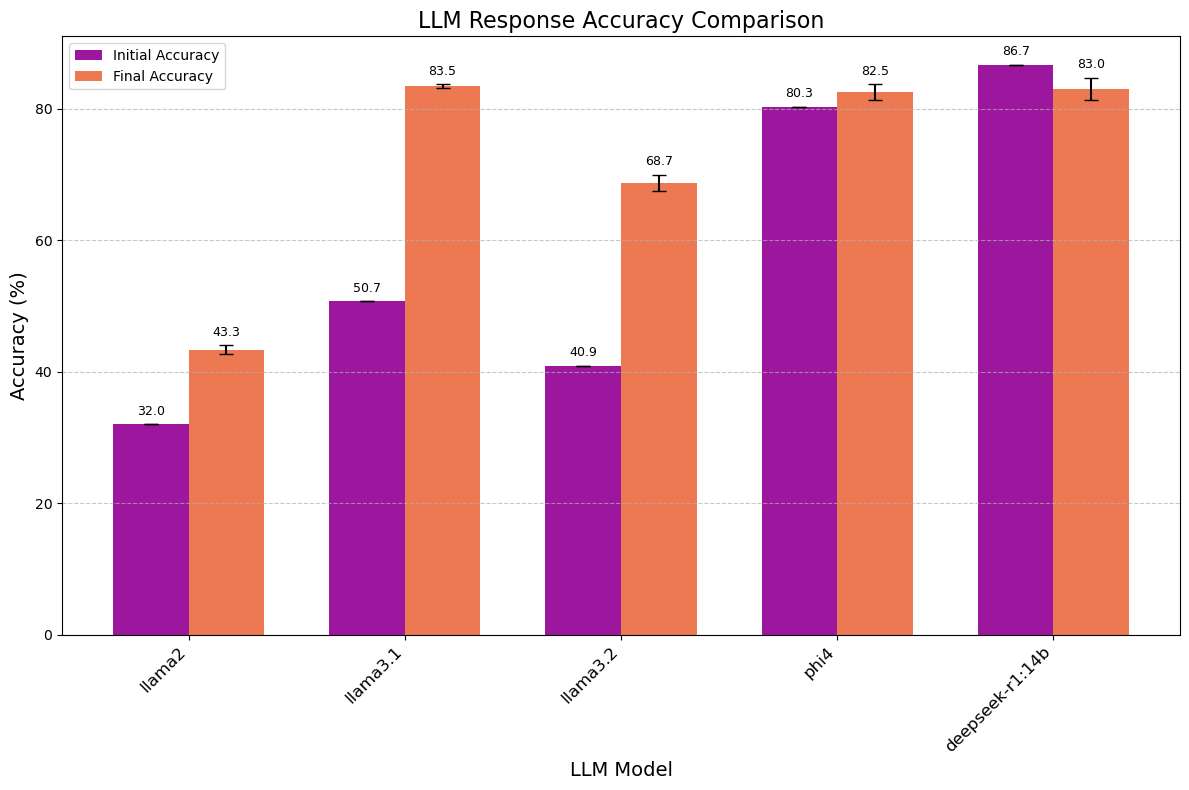

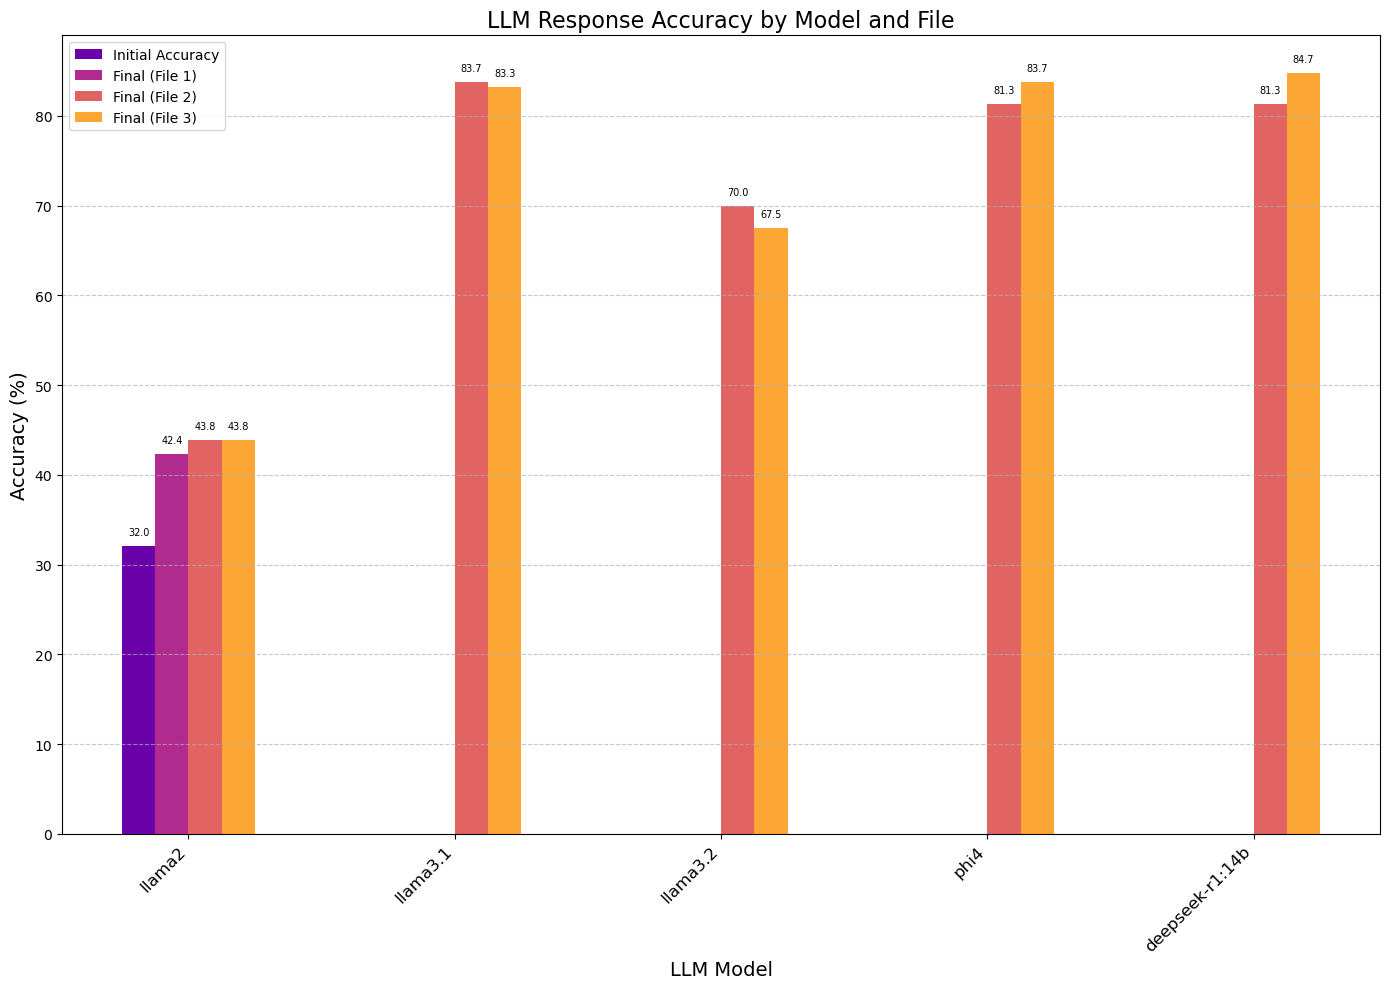

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from collections import defaultdict

def process_llm_response_file(file_path, target_models=None):
    """
    Process a LLM response file and extract metrics based on response correctness.
    
    Args:
        file_path: Path to the JSON file containing LLM responses
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        Dictionary with metrics for each model
    """
    try:
        # Load the JSON file
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Initialize metrics for each model
        model_metrics = defaultdict(lambda: {
            "initial_correct": 0,  # For raw_model_response
            "final_correct": 0,    # For onto_model_response
            "total": 0
        })
        
        # Process each item in the file
        for key, item in data.items():
            # Extract model name from the key (e.g., "llama2_0" -> "llama2")
            model_name = key.split("_")[0]
            
            # Skip if not in target models
            if target_models and not any(model_name.startswith(target) for target in target_models):
                continue
            
            try:
                # Get the correct answer
                correct_answer_index = int(item["question"]["answer"])
                choices = item["question"]["choices"]
                correct_answer = choices[correct_answer_index].lower()
                
                # Check for correctness in both raw and onto responses
                raw_response = item["raw_model_response"].lower()
                onto_response = item["onto_model_response"].lower()
                
                # Increment counters
                model_metrics[model_name]["total"] += 1
                
                if correct_answer in raw_response:
                    model_metrics[model_name]["initial_correct"] += 1
                
                if correct_answer in onto_response:
                    model_metrics[model_name]["final_correct"] += 1
                
            except (KeyError, IndexError, ValueError) as e:
                print(f"Error processing {key} in {file_path}: {e}")
                continue
        
        # Calculate percentages and other metrics
        results = {}
        for model, counts in model_metrics.items():
            if counts["total"] > 0:
                results[model] = {
                    "initial_accuracy": counts["initial_correct"] / counts["total"] * 100,
                    "final_accuracy": counts["final_correct"] / counts["total"] * 100,
                    "improvement": (counts["final_correct"] - counts["initial_correct"]) / counts["total"] * 100,
                    "initial_correct": counts["initial_correct"],
                    "final_correct": counts["final_correct"],
                    "total_questions": counts["total"]
                }
        
        print(f"Processed {os.path.basename(file_path)}: found data for {len(results)} models")
        return results
    
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
        return {}

def process_multiple_files(file_paths, target_models=None):
    """
    Process multiple LLM response files and combine the results.
    
    Args:
        file_paths: List of paths to JSON files
        target_models: List of model prefixes to include (or None for all)
        
    Returns:
        List of results dictionaries, one per file
    """
    all_results = []
    
    for file_path in file_paths:
        results = process_llm_response_file(file_path, target_models)
        if results:
            all_results.append(results)
    
    return all_results

def calculate_aggregate_statistics(all_results):
    """
    Calculate mean and standard deviation metrics across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        
    Returns:
        Tuple of (mean_metrics, std_metrics)
    """
    # Get all unique models
    all_models = set()
    for results in all_results:
        all_models.update(results.keys())
    
    # Initialize containers for aggregated metrics
    mean_metrics = {}
    std_metrics = {}
    
    for model in all_models:
        # Collect metrics for this model across all files
        initial_accuracies = []
        final_accuracies = []
        improvements = []
        initial_corrects = []
        final_corrects = []
        total_questions = []
        
        for results in all_results:
            if model in results:
                initial_accuracies.append(results[model]["initial_accuracy"])
                final_accuracies.append(results[model]["final_accuracy"])
                improvements.append(results[model]["improvement"])
                initial_corrects.append(results[model]["initial_correct"])
                final_corrects.append(results[model]["final_correct"])
                total_questions.append(results[model]["total_questions"])
        
        # Calculate means and standard deviations
        if initial_accuracies:  # Check if we have any data
            mean_metrics[model] = {
                "initial_accuracy": np.mean(initial_accuracies),
                "final_accuracy": np.mean(final_accuracies),
                "improvement": np.mean(improvements),
                "initial_correct": np.mean(initial_corrects),
                "final_correct": np.mean(final_corrects),
                "total_questions": np.mean(total_questions)
            }
            
            std_metrics[model] = {
                "initial_accuracy": np.std(initial_accuracies) if len(initial_accuracies) > 1 else 0,
                "final_accuracy": np.std(final_accuracies) if len(final_accuracies) > 1 else 0,
                "improvement": np.std(improvements) if len(improvements) > 1 else 0,
                "initial_correct": np.std(initial_corrects) if len(initial_corrects) > 1 else 0,
                "final_correct": np.std(final_corrects) if len(final_corrects) > 1 else 0,
                "total_questions": np.std(total_questions) if len(total_questions) > 1 else 0
            }
    
    return mean_metrics, std_metrics

def print_detailed_metrics(all_results, mean_metrics, std_metrics):
    """
    Print detailed metrics for each model.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
    """
    print("\n" + "=" * 80)
    print("DETAILED METRICS FOR LLM RESPONSES")
    print("=" * 80)
    
    # Get all models in alphabetical order
    models = sorted(mean_metrics.keys())
    
    for model in models:
        print(f"\nMODEL: {model}")
        print("-" * 80)
        
        # Print metrics for each file
        for i, results in enumerate(all_results):
            if model in results:
                print(f"File {i+1}:")
                print(f"  Initial Accuracy: {results[model]['initial_accuracy']:.2f}% ({results[model]['initial_correct']}/{results[model]['total_questions']})")
                print(f"  Final Accuracy:   {results[model]['final_accuracy']:.2f}% ({results[model]['final_correct']}/{results[model]['total_questions']})")
                print(f"  Improvement:      {results[model]['improvement']:.2f}%")
        
        # Print aggregate metrics
        print("\nAggregate Statistics:")
        print(f"  Initial Accuracy: {mean_metrics[model]['initial_accuracy']:.2f}% ± {std_metrics[model]['initial_accuracy']:.2f}%")
        print(f"  Final Accuracy:   {mean_metrics[model]['final_accuracy']:.2f}% ± {std_metrics[model]['final_accuracy']:.2f}%")
        print(f"  Improvement:      {mean_metrics[model]['improvement']:.2f}% ± {std_metrics[model]['improvement']:.2f}%")
        print(f"  Avg Questions:    {mean_metrics[model]['total_questions']:.1f}")
        
        # Calculate statistical significance
        if mean_metrics[model]['improvement'] > 0 and mean_metrics[model]['improvement'] > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant improvement **")
        elif mean_metrics[model]['improvement'] < 0 and abs(mean_metrics[model]['improvement']) > 2 * std_metrics[model]['improvement']:
            print("  ** Statistically significant degradation **")

def save_metrics_to_json(mean_metrics, std_metrics, output_file='llm_metrics_data_Answer.json'):
    """
    Save the calculated metrics to a JSON file.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        output_file: Path to the output file
    """
    # Get all models
    models = sorted(mean_metrics.keys())
    
    # Create serializable data
    data = {
        "llm_names": models,
        "mean_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                       for model, metrics in mean_metrics.items()},
        "std_metrics": {model: {k: float(v) for k, v in metrics.items()} 
                      for model, metrics in std_metrics.items()}
    }
    
    # Save to file
    with open(output_file, 'w') as f:
        json.dump(data, f, indent=4)
    
    print(f"Metrics saved to {output_file}")

def create_summary_plot(mean_metrics, std_metrics, ordered_models=None, output_file='llm_accuracy_comparison.png'):
    """
    Create a bar plot comparing initial and final accuracy for each model.
    
    Args:
        mean_metrics: Dictionary with mean metrics for each model
        std_metrics: Dictionary with standard deviation metrics for each model
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get models in specified order or alphabetically
    if ordered_models:
        models = [model for model in ordered_models if model in mean_metrics]
    else:
        models = sorted(mean_metrics.keys())
    
    # Extract metrics for plotting
    initial_accuracies = [mean_metrics[model]["initial_accuracy"] for model in models]
    final_accuracies = [mean_metrics[model]["final_accuracy"] for model in models]
    initial_errors = [std_metrics[model]["initial_accuracy"] for model in models]
    final_errors = [std_metrics[model]["final_accuracy"] for model in models]
    
    # Set up the figure
    plt.figure(figsize=(12, 8))
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.35
    
    # Use plasma colormap
    colors = sns.color_palette("plasma", 2)
    
    # Create the bar chart
    plt.bar(x - width/2, initial_accuracies, width, label='Initial Accuracy', 
            color=colors[0], yerr=initial_errors, capsize=5)
    plt.bar(x + width/2, final_accuracies, width, label='Final Accuracy', 
            color=colors[1], yerr=final_errors, capsize=5)
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy Comparison', fontsize=16)
    plt.xticks(x, models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        plt.text(i - width/2, v + initial_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    for i, v in enumerate(final_accuracies):
        plt.text(i + width/2, v + final_errors[i] + 1, f'{v:.1f}', 
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

def create_grouped_comparison_plot(all_results, ordered_models=None, output_file='llm_response_comparison_by_file.png'):
    """
    Create a grouped bar plot showing final accuracy for each model across all files.
    
    Args:
        all_results: List of dictionaries with metrics for each model by file
        ordered_models: List of models in the desired order (or None for alphabetical)
        output_file: Path to the output file
    """
    # Get all unique models
    all_model_names = set()
    for results in all_results:
        all_model_names.update(results.keys())
    
    # Use specified order or alphabetical
    if ordered_models:
        models = [model for model in ordered_models if model in all_model_names]
    else:
        models = sorted(list(all_model_names))
    
    # Set up the figure
    plt.figure(figsize=(14, 10))
    
    # Set up the bar positions
    file_count = len(all_results)
    bar_width = 0.2
    group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
    group_positions = np.arange(len(models)) * (group_width + 0.8)
    
    # Use plasma colormap
    plasma_colors = sns.color_palette("plasma", file_count + 1)
    
    # Plot initial accuracies (only once per model - from first file)
    initial_positions = group_positions
    initial_accuracies = []
    
    for model in models:
        if model in all_results[0]:
            initial_accuracies.append(all_results[0][model]["initial_accuracy"])
        else:
            initial_accuracies.append(0)
    
    plt.bar(
        initial_positions, 
        initial_accuracies, 
        bar_width, 
        color=plasma_colors[0], 
        label="Initial Accuracy"
    )
    
    # Plot final accuracies from each file
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        final_accuracies = []
        
        for model in models:
            if model in results:
                final_accuracies.append(results[model]["final_accuracy"])
            else:
                final_accuracies.append(0)
        
        plt.bar(
            final_positions, 
            final_accuracies, 
            bar_width, 
            color=plasma_colors[file_idx + 1], 
            label=f"Final (File {file_idx + 1})"
        )
    
    # Add labels and formatting
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('LLM Response Accuracy by Model and File', fontsize=16)
    plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), models, rotation=45, ha='right', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    # Add value labels (without % sign)
    for i, v in enumerate(initial_accuracies):
        if v > 0:
            plt.text(
                initial_positions[i],
                v + 1,
                f'{v:.1f}',
                ha='center', va='bottom', fontsize=7
            )
    
    # Add value labels for final accuracies
    for file_idx, results in enumerate(all_results):
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        for i, model in enumerate(models):
            if model in results and results[model]["final_accuracy"] > 0:
                plt.text(
                    final_positions[i],
                    results[model]["final_accuracy"] + 1,
                    f'{results[model]["final_accuracy"]:.1f}',
                    ha='center', va='bottom', fontsize=7
                )
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Grouped comparison plot saved to {output_file}")

# Main execution
if __name__ == "__main__":
    # Define the file paths
    file_paths = [
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation2.json"
    ]
    
    # Define target models
    target_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek"]
    
    # Define model order for plots
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Process the files
    all_results = process_multiple_files(file_paths, target_models)
    
    if all_results:
        # Calculate aggregate statistics
        mean_metrics, std_metrics = calculate_aggregate_statistics(all_results)
        
        # Print detailed metrics
        print_detailed_metrics(all_results, mean_metrics, std_metrics)
        
        # Save metrics to JSON
        save_metrics_to_json(mean_metrics, std_metrics)
        
        # Create plots
        create_summary_plot(mean_metrics, std_metrics, ordered_models)
        create_grouped_comparison_plot(all_results, ordered_models)
        
        print("\nProcessing complete!")
    else:
        print("No valid data was processed.")

In [ ]:
'/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Question.json'
'/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Answer.json'
'/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Dual.json'

Loaded /home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Question.json
Loaded /home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Answer.json
Loaded /home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Dual.json


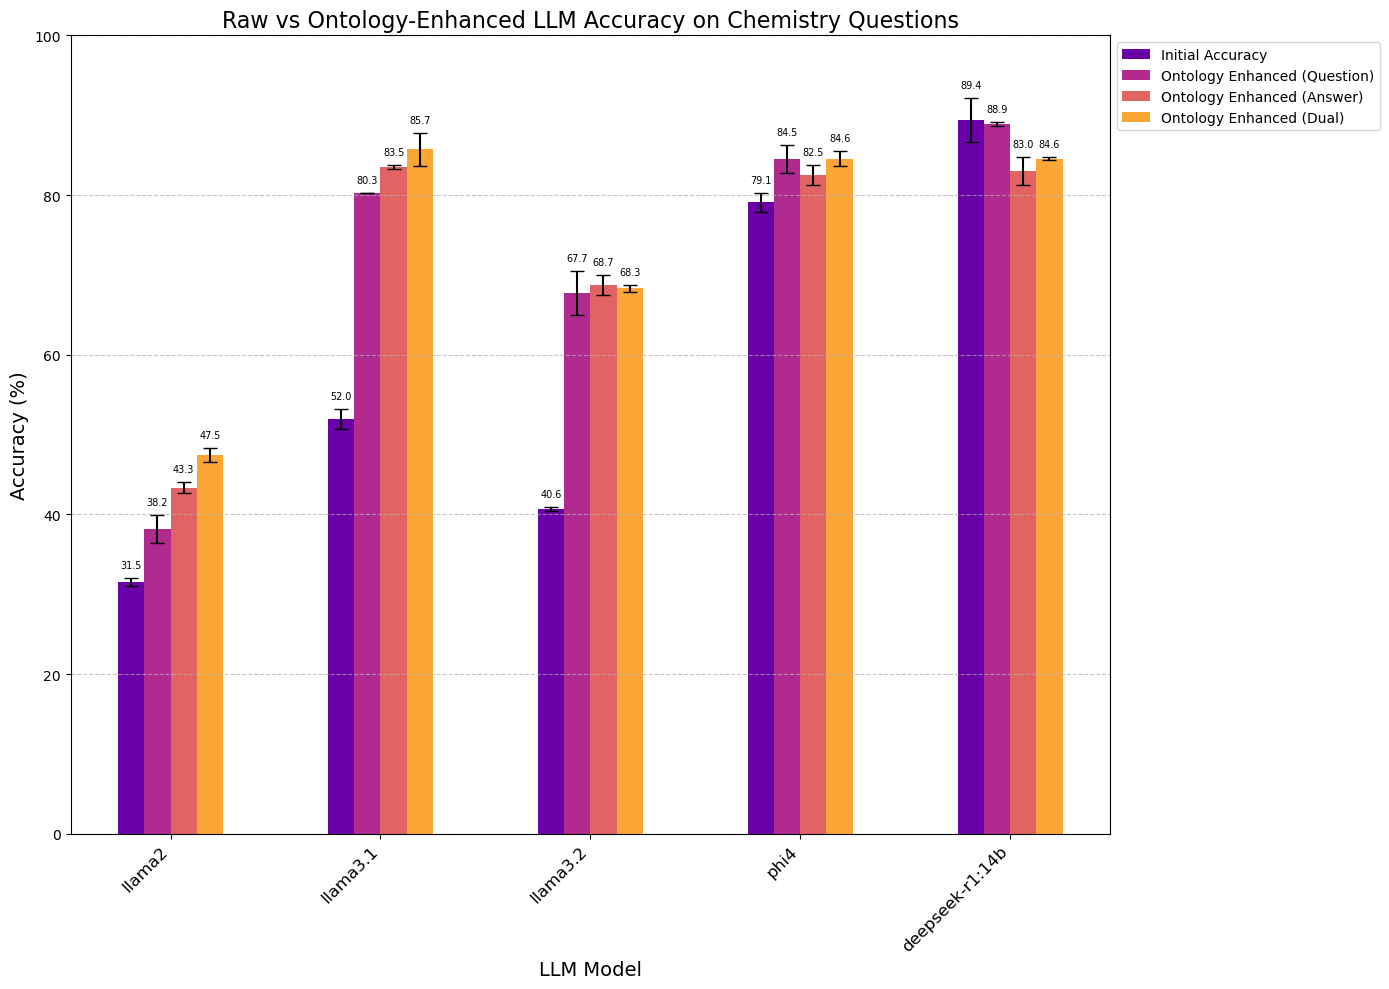

Visualization saved as 'llm_accuracy_comparison.png'


In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import defaultdict

# Load spaCy for concept extraction
nlp = spacy.load("en_core_web_sm")

# Define file paths
file_paths = [
    '/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Question.json',
    '/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Answer.json',
    '/home/matt/Proj/Hermeticav2/notebooks/Viz/llm_metrics_data_Dual.json'
]

# Use descriptive names for each file/experiment
file_labels = [
    "Question",
    "Answer", 
    "Dual"
]

def analyze_file(file_path):
    """Analyze a single JSON file and return metrics."""
    # Initialize results
    file_results = defaultdict(lambda: {
        "initial_correct": 0,
        "final_correct": 0,
        "total_questions": 0
    })
    
    # Load the data
    with open(file_path, "r") as file:
        data = json.load(file)
    
    # Process each entry in the file
    for key, item in data.items():
        # Skip if doesn't have required fields
        if "question" not in item:
            continue
            
        # Get model name (like "llama2" from "llama2_0")
        model_name = key.split("_")[0]
        
        # Get the correct answer
        question = item["question"]
        correct_answer_index = int(question["answer"])
        correct_answer = question["choices"][correct_answer_index].lower()
        
        # Get the responses
        initial_response = item.get("raw_model_response", "").lower()
        final_response = item.get("onto_model_response", "").lower()
        
        # Check if correct answer appears in responses
        initial_correct = correct_answer in initial_response
        final_correct = correct_answer in final_response
        
        # Update accuracy counts
        if initial_correct:
            file_results[model_name]["initial_correct"] += 1
        if final_correct:
            file_results[model_name]["final_correct"] += 1
        
        file_results[model_name]["total_questions"] += 1
    
    return file_results

def save_metrics_to_json(all_results, file_labels):
    """Create JSON files with mean and std metrics for each experiment."""
    for idx, (results, label) in enumerate(zip(all_results, file_labels)):
        # Get all models from this experiment
        llm_names = sorted(results.keys())
        
        # Calculate metrics
        mean_metrics = {}
        std_metrics = {}
        
        for model_name in llm_names:
            metrics = results[model_name]
            total = metrics["total_questions"]
            
            if total > 0:
                # Calculate percentages
                initial_accuracy = (metrics["initial_correct"] / total) * 100
                final_accuracy = (metrics["final_correct"] / total) * 100
                
                # Store in mean_metrics
                mean_metrics[model_name] = {
                    "initial_accuracy": initial_accuracy,
                    "final_accuracy": final_accuracy,
                    "accuracy_improvement": final_accuracy - initial_accuracy,
                    "total_questions": total,
                    "initial_correct": metrics["initial_correct"],
                    "final_correct": metrics["final_correct"]
                }
                
                # For this simple version, we'll use zero std dev since we're only using one file per experiment
                std_metrics[model_name] = {
                    "initial_accuracy": 0,
                    "final_accuracy": 0,
                    "accuracy_improvement": 0,
                    "total_questions": 0,
                    "initial_correct": 0,
                    "final_correct": 0
                }
        
        # Create output structure
        output = {
            "llm_names": llm_names,
            "mean_metrics": mean_metrics,
            "std_metrics": std_metrics
        }
        
        # Save to file
        output_file = f"llm_metrics_data_{label}.json"
        with open(output_file, "w") as f:
            json.dump(output, f, indent=4)
        
        print(f"Saved metrics for {label} to {output_file}")

def create_visualization(file_paths, file_labels):
    """Create a visualization from the JSON files."""
    # Load data from all files
    all_data = []
    for file_path in file_paths:
        try:
            with open(file_path, 'r') as f:
                all_data.append(json.load(f))
                print(f"Loaded {file_path}")
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Check if we have any valid data
    if not all_data:
        print("No valid data found. Exiting.")
        return
    
    # Define the specific order of models
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Filter to models present in the data
    all_models = [model for model in ordered_models if any(model in data["mean_metrics"] for data in all_data)]
    
    # Prepare data for plotting
    file_count = len(all_data)
    model_count = len(all_models)
    
    # Initialize arrays for initial and final accuracies and their error bars
    initial_accuracies = np.zeros(model_count)
    initial_errors = np.zeros(model_count)
    final_accuracies = np.zeros((model_count, file_count))
    final_errors = np.zeros((model_count, file_count))
    
    # Fill the arrays with data - using only first file for initial values
    for model_idx, model_name in enumerate(all_models):
        if model_name in all_data[0]["mean_metrics"]:
            initial_accuracies[model_idx] = all_data[0]["mean_metrics"][model_name]["initial_accuracy"]
            initial_errors[model_idx] = all_data[0]["std_metrics"][model_name]["initial_accuracy"]
    
    # Fill the final accuracy arrays with data from each file
    for file_idx, data in enumerate(all_data):
        for model_idx, model_name in enumerate(all_models):
            if model_name in data["mean_metrics"]:
                final_accuracies[model_idx, file_idx] = data["mean_metrics"][model_name]["final_accuracy"]
                final_errors[model_idx, file_idx] = data["std_metrics"][model_name]["final_accuracy"]
    
    # Create a figure
    plt.figure(figsize=(14, 10))
    
    # Set up the bar positions
    bar_width = 0.2
    group_width = bar_width * (file_count + 1)  # +1 for initial accuracy
    group_positions = np.arange(model_count) * (group_width + 0.8)  # Position of each model group
    
    # Use seaborn's plasma palette
    plasma_colors = sns.color_palette("plasma", file_count + 1)
    
    # Plot initial accuracies first (only once per model)
    initial_positions = group_positions
    initial_bars = plt.bar(
        initial_positions, 
        initial_accuracies, 
        bar_width, 
        yerr=initial_errors, 
        capsize=5, 
        color=plasma_colors[0], 
        label="Initial Accuracy"
    )
    
    # Create the grouped bar chart for final accuracies
    for file_idx in range(file_count):
        # Calculate positions for this file's bars - position after initial bar
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        # Plot final accuracies
        plt.bar(
            final_positions, 
            final_accuracies[:, file_idx], 
            bar_width, 
            yerr=final_errors[:, file_idx], 
            capsize=5, 
            color=plasma_colors[file_idx + 1], 
            label=f"Ontology Enhanced ({file_labels[file_idx]})"
        )
    
    # Add labels and title
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.title('Raw vs Ontology-Enhanced LLM Accuracy on Chemistry Questions', fontsize=16)
    
    # Set x-ticks at the center of each group
    plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)
    
    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis range from 0 to 100 (for percentage)
    plt.ylim(0, 100)
    
    # Add value labels on top of initial bars with smaller font
    for i, model_idx in enumerate(range(model_count)):
        if initial_accuracies[model_idx] > 0:
            plt.text(
                initial_positions[i],
                initial_accuracies[model_idx] + initial_errors[model_idx] + 1,
                f'{initial_accuracies[model_idx]:.1f}',
                ha='center', va='bottom', fontsize=18
            )
    
    # Add value labels on top of final bars with smaller font
    for file_idx in range(file_count):
        final_positions = group_positions + bar_width * (file_idx + 1)
        
        for i, model_idx in enumerate(range(model_count)):
            if final_accuracies[model_idx, file_idx] > 0:
                plt.text(
                    final_positions[i],
                    final_accuracies[model_idx, file_idx] + final_errors[model_idx, file_idx] + 1,
                    f'{final_accuracies[model_idx, file_idx]:.1f}',
                    ha='center', va='bottom', fontsize=18
                )
    
    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
    
    plt.tight_layout()
    plt.savefig('llm_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved as 'llm_accuracy_comparison.png'")

# Main execution flow
def main():
    # Option 1: If you want to regenerate the JSON files
    regenerate_json = False
    
    if regenerate_json:
        # Analyze each file
        all_results = []
        for file_path in file_paths:
            print(f"Analyzing {file_path}...")
            file_result = analyze_file(file_path)
            all_results.append(file_result)
        
        # Save metrics to JSON files
        save_metrics_to_json(all_results, file_labels)
    
    # Create visualization from the JSON files (either existing or newly generated)
    create_visualization(file_paths, file_labels)

# Run the main function
main()


Processing Question experiment...
Analyzing MMLU_highschool_Chem_Full.json...
Analyzing MMLU_highschool_Chem_Full1.json...
Analyzing MMLU_highschool_Chem_Full2.json...

Processing Answer experiment...
Analyzing MMLU_highschool_Chem_Full_A_annotation.json...
Analyzing MMLU_highschool_Chem_Full_A_annotation1.json...
Analyzing MMLU_highschool_Chem_Full_A_annotation2.json...

Processing Dual experiment...
Analyzing MMLU_highschool_Chem_Full_Dual_annotation0.json...
Analyzing MMLU_highschool_Chem_Full_Dual_annotation1.json...
Analyzing MMLU_highschool_Chem_Full_Dual_annotation2.json...
Saved concept coverage metrics for Question to llm_concept_coverage_Question.json
Saved concept coverage metrics for Answer to llm_concept_coverage_Answer.json
Saved concept coverage metrics for Dual to llm_concept_coverage_Dual.json


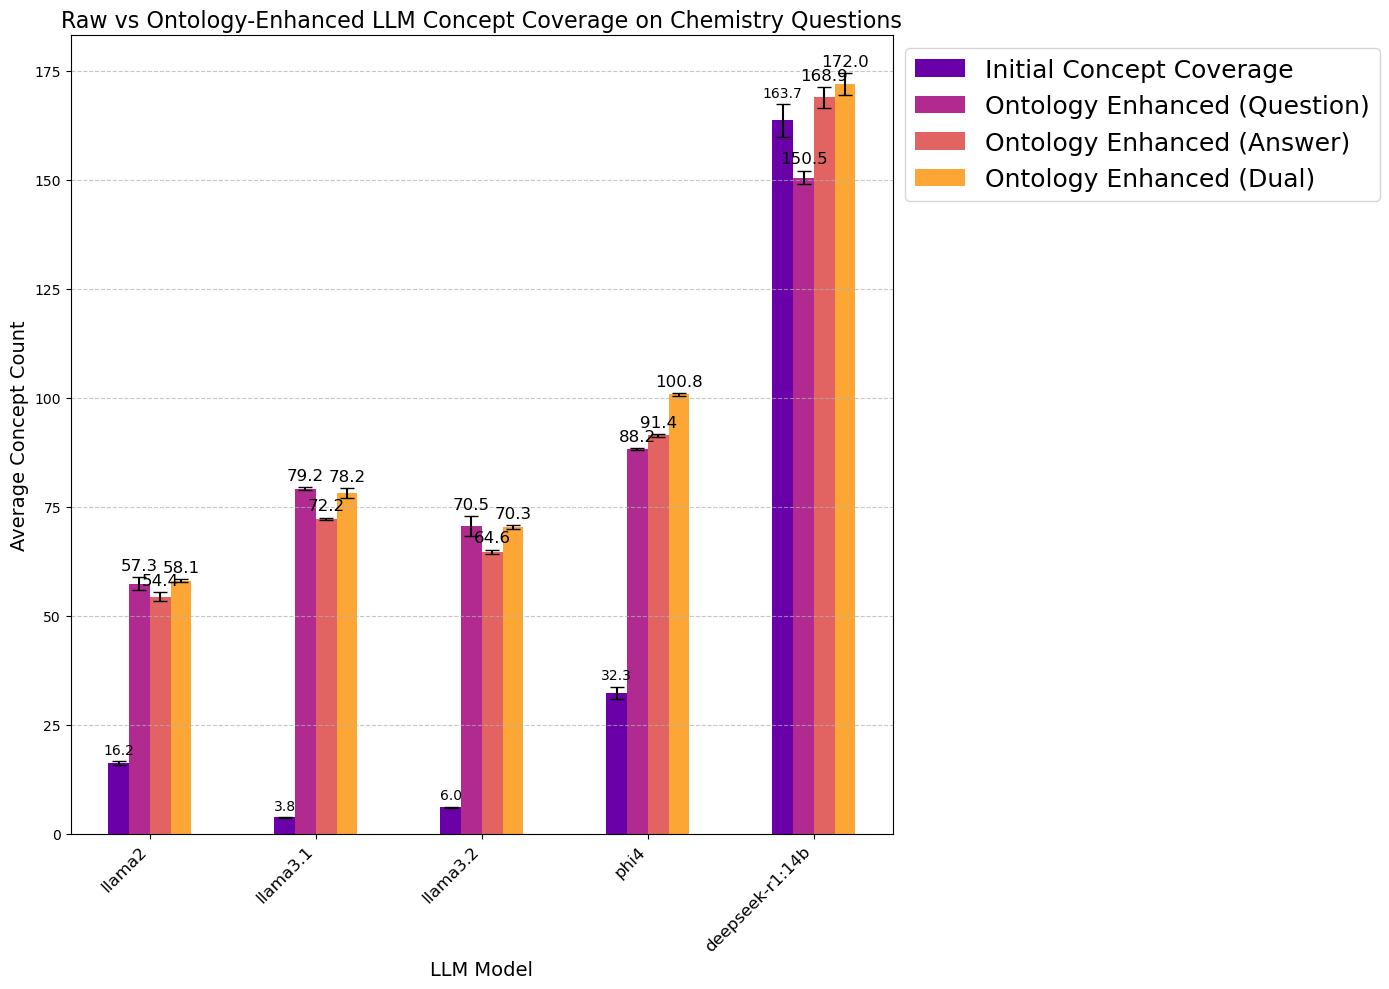

Concept coverage visualization saved as 'llm_concept_coverage_comparison.png'


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import defaultdict
import os

# Load spaCy for concept extraction
nlp = spacy.load("en_core_web_sm")

# Define file paths organized by experiment type
file_paths_by_experiment = {
    "Question": [
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full1.json",
        "/home/matt/Proj/Hermeticav2/results/QAnnotationOnly/MMLU_highschool_Chem_Full2.json"
    ],
    "Answer": [
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation2.json"
    ],
    "Dual": [
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation1.json",
        "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation2.json"
    ]
}

# Experiment labels for plotting
experiment_labels = ["Question", "Answer", "Dual"]

def extract_entities_and_keywords(text):
    """
    Extract entities and key concepts from text using spaCy.
    """
    if not text or not isinstance(text, str):
        return set()
        
    doc = nlp(text)
    
    # Get named entities
    entities = set([ent.text.lower() for ent in doc.ents])
    
    # Get noun chunks (concepts)
    noun_chunks = set([chunk.text.lower() for chunk in doc.noun_chunks])
    
    # Get key scientific terms using POS patterns
    science_terms = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"] and len(token.text) > 3:
            science_terms.add(token.text.lower())
    
    # Combine all concepts
    all_concepts = entities.union(noun_chunks).union(science_terms)
    return all_concepts

def analyze_file(file_path):
    """
    Analyze a single JSON file for accuracy and concept coverage.
    
    Args:
        file_path (str): Path to JSON file
        
    Returns:
        dict: Metrics for each LLM model
    """
    # Initialize results for this file
    file_results = defaultdict(lambda: {
        "raw_correct": 0, 
        "onto_correct": 0, 
        "total": 0,
        "raw_concept_coverage": [],
        "onto_concept_coverage": []
    })
    
    try:
        with open(file_path, "r") as file:
            data = json.load(file)
            
            # Process each entry in the file
            for key, item in data.items():
                # Extract model name (assuming format like "llama2_0")
                model_name = key.split("_")[0]
                
                # Skip if item doesn't have required fields
                if "question" not in item:
                    continue
                
                # Extract question details
                question = item["question"]
                correct_index = int(question["answer"])
                choices = question["choices"]
                correct_answer = choices[correct_index].lower()
                
                # Get model responses
                raw_response = item.get("raw_model_response", "")
                onto_response = item.get("onto_model_response", "")
                
                # Check accuracy by seeing if the correct answer is in the response
                raw_correct = correct_answer in raw_response.lower() if raw_response else False
                onto_correct = correct_answer in onto_response.lower() if onto_response else False
                
                # Update accuracy metrics
                if raw_correct:
                    file_results[model_name]["raw_correct"] += 1
                if onto_correct:
                    file_results[model_name]["onto_correct"] += 1
                
                file_results[model_name]["total"] += 1
                
                # Analyze concept coverage
                raw_concepts = extract_entities_and_keywords(raw_response)
                onto_concepts = extract_entities_and_keywords(onto_response)
                
                # Store concept metrics
                file_results[model_name]["raw_concept_coverage"].append(len(raw_concepts))
                file_results[model_name]["onto_concept_coverage"].append(len(onto_concepts))
                
    except Exception as e:
        print(f"Error processing file {file_path}: {e}")
    
    return file_results

def calculate_metrics_for_experiment(file_paths):
    """
    Calculate metrics across multiple files for one experiment type.
    
    Args:
        file_paths (list): List of paths to JSON files for this experiment
        
    Returns:
        dict: Aggregated metrics across files
    """
    # Analyze each file
    all_file_results = []
    for file_path in file_paths:
        print(f"Analyzing {os.path.basename(file_path)}...")
        file_result = analyze_file(file_path)
        all_file_results.append(file_result)
    
    # Initialize aggregated metrics
    aggregated_metrics = {
        "accuracy": defaultdict(list),
        "concept_coverage": defaultdict(list)
    }
    
    # Combine results across files
    for file_result in all_file_results:
        for model_name, metrics in file_result.items():
            if metrics["total"] > 0:
                # Calculate accuracy percentages
                raw_accuracy = (metrics["raw_correct"] / metrics["total"]) * 100
                onto_accuracy = (metrics["onto_correct"] / metrics["total"]) * 100
                
                # Store accuracy metrics
                aggregated_metrics["accuracy"][model_name].append({
                    "raw_accuracy": raw_accuracy,
                    "onto_accuracy": onto_accuracy,
                    "total": metrics["total"]
                })
                
                # Calculate average concept coverage
                avg_raw_concepts = np.mean(metrics["raw_concept_coverage"])
                avg_onto_concepts = np.mean(metrics["onto_concept_coverage"])
                
                # Store concept coverage metrics
                aggregated_metrics["concept_coverage"][model_name].append({
                    "raw_concept_coverage": avg_raw_concepts,
                    "onto_concept_coverage": avg_onto_concepts
                })
    
    return aggregated_metrics

def calculate_summary_metrics(aggregated_metrics):
    """
    Calculate mean and std metrics from the aggregated data.
    
    Args:
        aggregated_metrics (dict): Aggregated metrics across files
        
    Returns:
        dict: Mean and std metrics
    """
    all_models = set()
    for model_dict in [aggregated_metrics["accuracy"], aggregated_metrics["concept_coverage"]]:
        all_models.update(model_dict.keys())
    
    mean_metrics = {}
    std_metrics = {}
    
    for model_name in all_models:
        # Initialize dictionaries
        mean_metrics[model_name] = {}
        std_metrics[model_name] = {}
        
        # Process accuracy metrics
        if model_name in aggregated_metrics["accuracy"]:
            accuracy_data = aggregated_metrics["accuracy"][model_name]
            
            raw_accuracies = [data["raw_accuracy"] for data in accuracy_data]
            onto_accuracies = [data["onto_accuracy"] for data in accuracy_data]
            totals = [data["total"] for data in accuracy_data]
            
            # Calculate means
            mean_metrics[model_name]["initial_accuracy"] = np.mean(raw_accuracies)
            mean_metrics[model_name]["final_accuracy"] = np.mean(onto_accuracies)
            mean_metrics[model_name]["accuracy_improvement"] = np.mean([onto - raw for onto, raw in zip(onto_accuracies, raw_accuracies)])
            mean_metrics[model_name]["total_questions"] = np.mean(totals)
            mean_metrics[model_name]["initial_correct"] = np.mean([raw_acc * total / 100 for raw_acc, total in zip(raw_accuracies, totals)])
            mean_metrics[model_name]["final_correct"] = np.mean([onto_acc * total / 100 for onto_acc, total in zip(onto_accuracies, totals)])
            
            # Calculate stds
            std_metrics[model_name]["initial_accuracy"] = np.std(raw_accuracies)
            std_metrics[model_name]["final_accuracy"] = np.std(onto_accuracies)
            std_metrics[model_name]["accuracy_improvement"] = np.std([onto - raw for onto, raw in zip(onto_accuracies, raw_accuracies)])
            std_metrics[model_name]["total_questions"] = np.std(totals)
            std_metrics[model_name]["initial_correct"] = np.std([raw_acc * total / 100 for raw_acc, total in zip(raw_accuracies, totals)])
            std_metrics[model_name]["final_correct"] = np.std([onto_acc * total / 100 for onto_acc, total in zip(onto_accuracies, totals)])
        
        # Process concept coverage metrics
        if model_name in aggregated_metrics["concept_coverage"]:
            concept_data = aggregated_metrics["concept_coverage"][model_name]
            
            raw_concepts = [data["raw_concept_coverage"] for data in concept_data]
            onto_concepts = [data["onto_concept_coverage"] for data in concept_data]
            
            # Calculate means
            mean_metrics[model_name]["initial_concept_coverage"] = np.mean(raw_concepts)
            mean_metrics[model_name]["final_concept_coverage"] = np.mean(onto_concepts)
            mean_metrics[model_name]["concept_improvement"] = np.mean([onto - raw for onto, raw in zip(onto_concepts, raw_concepts)])
            
            # Calculate stds
            std_metrics[model_name]["initial_concept_coverage"] = np.std(raw_concepts)
            std_metrics[model_name]["final_concept_coverage"] = np.std(onto_concepts)
            std_metrics[model_name]["concept_improvement"] = np.std([onto - raw for onto, raw in zip(onto_concepts, raw_concepts)])
    
    return mean_metrics, std_metrics

def create_concept_coverage_json(experiment_labels, metrics_by_experiment):
    """Create JSON files for each experiment with concept coverage metrics."""
    for exp_label, (mean_metrics, std_metrics) in zip(experiment_labels, metrics_by_experiment):
        # Get all models from this experiment
        all_models = sorted(mean_metrics.keys())
        
        # Create output structure
        output = {
            "llm_names": all_models,
            "mean_metrics": mean_metrics,
            "std_metrics": std_metrics
        }
        
        # Save to file
        output_file = f"llm_concept_coverage_{exp_label}.json"
        with open(output_file, "w") as f:
            json.dump(output, f, indent=4)
        
        print(f"Saved concept coverage metrics for {exp_label} to {output_file}")

def plot_concept_coverage(experiment_labels, metrics_by_experiment):
    """Create a bar chart showing concept coverage across experiments."""
    # Define the specific order of models
    ordered_models = ["llama2", "llama3.1", "llama3.2", "phi4", "deepseek-r1:14b"]
    
    # Get all models across all experiments
    all_models_set = set()
    for mean_metrics, _ in metrics_by_experiment:
        all_models_set.update(mean_metrics.keys())
    
    # Filter by the ordered models and keep only those present in the data
    all_models = [model for model in ordered_models if model in all_models_set]
    model_count = len(all_models)
    experiment_count = len(experiment_labels)
    
    # Initialize arrays for initial and final concept coverage and their error bars
    initial_coverage = np.zeros(model_count)
    initial_errors = np.zeros(model_count)
    final_coverage = np.zeros((model_count, experiment_count))
    final_errors = np.zeros((model_count, experiment_count))
    
    # Fill initial concept coverage from first experiment
    mean_metrics_first, std_metrics_first = metrics_by_experiment[0]
    for model_idx, model_name in enumerate(all_models):
        if model_name in mean_metrics_first:
            initial_coverage[model_idx] = mean_metrics_first[model_name].get("initial_concept_coverage", 0)
            initial_errors[model_idx] = std_metrics_first[model_name].get("initial_concept_coverage", 0)
    
    # Fill final concept coverage from all experiments
    for exp_idx, (mean_metrics, std_metrics) in enumerate(metrics_by_experiment):
        for model_idx, model_name in enumerate(all_models):
            if model_name in mean_metrics:
                final_coverage[model_idx, exp_idx] = mean_metrics[model_name].get("final_concept_coverage", 0)
                final_errors[model_idx, exp_idx] = std_metrics[model_name].get("final_concept_coverage", 0)
    
    # Create a figure
    plt.figure(figsize=(14, 10))
    
    # Set up the bar positions
    bar_width = 0.2
    group_width = bar_width * (experiment_count + 1)  # +1 for initial coverage
    group_positions = np.arange(model_count) * (group_width + 0.8)  # Position of each model group
    
    # Use seaborn's plasma palette
    plasma_colors = sns.color_palette("plasma", experiment_count + 1)
    
    # Plot initial concept coverage
    initial_positions = group_positions
    plt.bar(
        initial_positions, 
        initial_coverage, 
        bar_width, 
        yerr=initial_errors, 
        capsize=5, 
        color=plasma_colors[0], 
        label="Initial Concept Coverage"
    )
    
    # Plot final concept coverage for each experiment
    for exp_idx in range(experiment_count):
        # Calculate positions for this experiment's bars
        final_positions = group_positions + bar_width * (exp_idx + 1)
        
        # Plot final concept coverage
        plt.bar(
            final_positions, 
            final_coverage[:, exp_idx], 
            bar_width, 
            yerr=final_errors[:, exp_idx], 
            capsize=5, 
            color=plasma_colors[exp_idx + 1], 
            label=f"Ontology Enhanced ({experiment_labels[exp_idx]})"
        )
    
    # Add labels and title
    plt.xlabel('LLM Model', fontsize=14)
    plt.ylabel('Average Concept Count', fontsize=14)
    plt.title('Raw vs Ontology-Enhanced LLM Concept Coverage on Chemistry Questions', fontsize=16)
    
    # Set x-ticks at the center of each group
    plt.xticks(group_positions + (group_width / 2) - (bar_width / 2), all_models, rotation=45, ha='right', fontsize=12)
    
    # Add grid lines for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of bars
    for i, model_idx in enumerate(range(model_count)):
        if initial_coverage[model_idx] > 0:
            plt.text(
                initial_positions[i],
                initial_coverage[model_idx] + initial_errors[model_idx] + 1,
                f'{initial_coverage[model_idx]:.1f}',
                ha='center', va='bottom', fontsize=10
            )
    
    # Add value labels for final concept coverage
    for exp_idx in range(experiment_count):
        final_positions = group_positions + bar_width * (exp_idx + 1)
        
        for i, model_idx in enumerate(range(model_count)):
            if final_coverage[model_idx, exp_idx] > 0:
                plt.text(
                    final_positions[i],
                    final_coverage[model_idx, exp_idx] + final_errors[model_idx, exp_idx] + 1,
                    f'{final_coverage[model_idx, exp_idx]:.1f}',
                    ha='center', va='bottom', fontsize=12
                )
    
    # Add a legend
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1,fontsize=18)
    
    plt.tight_layout()
    plt.savefig('llm_concept_coverage_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Concept coverage visualization saved as 'llm_concept_coverage_comparison.png'")

def main():
    # Process each experiment type
    metrics_by_experiment = []
    
    for exp_label in experiment_labels:
        print(f"\nProcessing {exp_label} experiment...")
        exp_files = file_paths_by_experiment[exp_label]
        aggregated_metrics = calculate_metrics_for_experiment(exp_files)
        mean_metrics, std_metrics = calculate_summary_metrics(aggregated_metrics)
        metrics_by_experiment.append((mean_metrics, std_metrics))
    
    # Create JSON files for concept coverage
    create_concept_coverage_json(experiment_labels, metrics_by_experiment)
    
    # Create concept coverage visualization
    plot_concept_coverage(experiment_labels, metrics_by_experiment)

if __name__ == "__main__":
    main()